In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

In [7]:
from pathlib import Path
import csv

import scanpy as sc


In [20]:
data_splits = {
    "train_smiles": np.array([445715, 422554, 456155, 442308, 416771]),
    "valid_smiles": np.array([137181, 160347, 126746, 140593, 166130]),
    "test_smiles": np.array([145729, 145724, 145724, 145724, 145724]),
    "train_fingerprints": np.array([439130, 442442, 441295, 438592, 428413]),
    "valid_fingerprints": np.array([143769, 140457, 141604, 144307, 154491]),
    "test_fingerprints": np.array([145726, 145726, 145726, 145726, 145721])
}
dataframe_splits = pd.DataFrame(data=data_splits)
df_swarmplot = dataframe_splits.melt(var_name="split_type", value_name="observation_count")


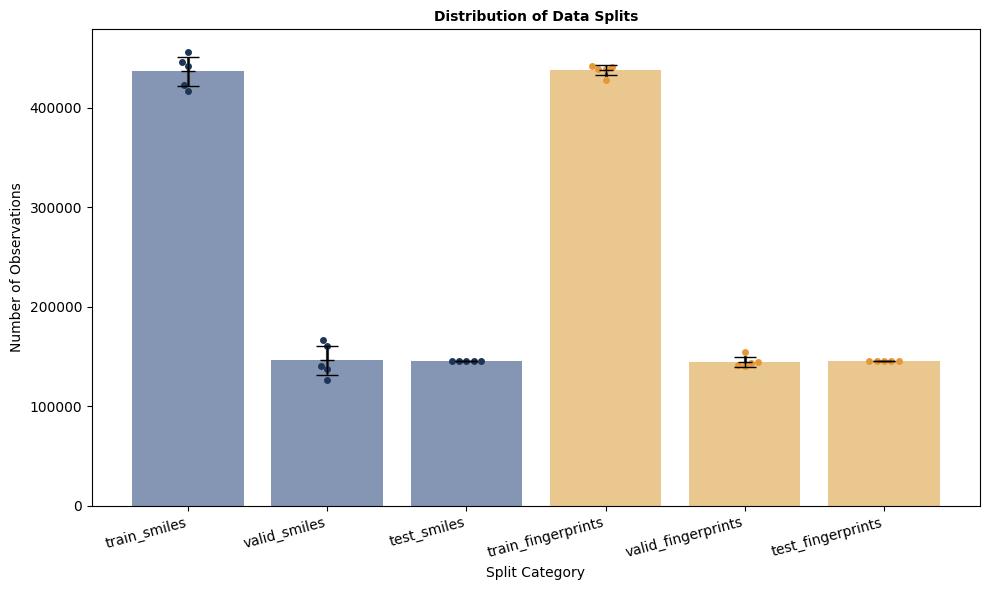

In [52]:
plt.figure(figsize=(10, 6))

bar_colors = {"smiles": "#7c94bb", "fingerprints": "#f8ca80"}   
dot_colors = {"smiles": "#1d3557", "fingerprints": "#e69839"}   

# 2. Extract unique categories in order
categories = df_swarmplot["split_type"].unique()

# 3. Plot each category column individually
for i, cat in enumerate(categories):
    dtype = "smiles" if "smiles" in cat else "fingerprints"
    sub_df = df_swarmplot[df_swarmplot["split_type"] == cat]
    values = sub_df["observation_count"].to_numpy()
    
    # Draw the swarm dots for this column
    sns.swarmplot(
        data=sub_df,
        x="split_type",
        y="observation_count",
        color=dot_colors[dtype],
        #size=6,
    )

    # Draw bar for this column
    sns.barplot(
        data=sub_df,
        x="split_type",
        y="observation_count",
        color=bar_colors[dtype],
    )
    
    # Calculate Summary Statistics: Mean and Standard Deviation
    group_mean = np.mean(values)
    std_val = np.std(values)  # Direct standard deviation calculation
    
    # 4. Draw the separate error bars (Mean and 1 SD)
    plt.errorbar(
        x=i, 
        y=group_mean, 
        yerr=std_val,                  
        fmt='_',                       
        color="black", 
        markersize=10,                 
        markeredgewidth=1,            
        elinewidth=1,                
        capsize=8,                     
        capthick=2,                    
        zorder=3                       
    )

# 5. Clean up layout aesthetics
plt.xticks(rotation=15, ha="right")
plt.title("Distribution of Data Splits", fontsize=10, fontweight="bold")
plt.ylabel("Number of Observations")
plt.xlabel("Split Category")


plt.tight_layout()
plt.show()

##### Loss curves showing results of smoke test

In [8]:
training_res_smiles_split = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_04/training_canonical_smiles")



<Axes: xlabel='Unnamed: 0', ylabel='Loss_PGM'>

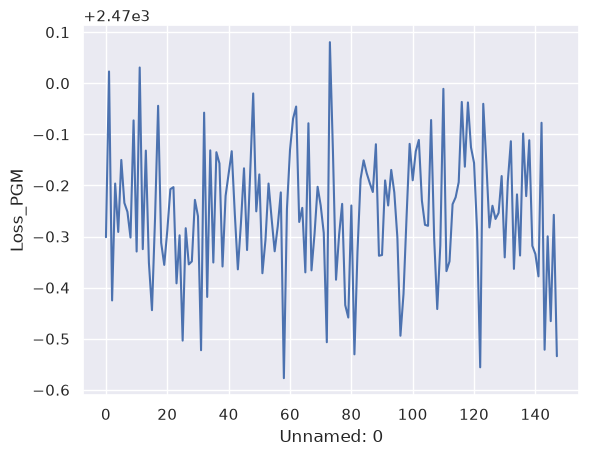

In [21]:
sns.set_theme(style="darkgrid")

loss_df_0 = pd.read_csv(training_res_smiles_split / "canonical_smiles_split_0loss_comb.csv")
loss_df_0['Split'] = pd.Series([0 for x in range(len(loss_df_0.index))])

sns.lineplot(x="Unnamed: 0", y="Loss_PGM", data=fmri)

<Axes: xlabel='Unnamed: 0', ylabel='Loss_PGM'>

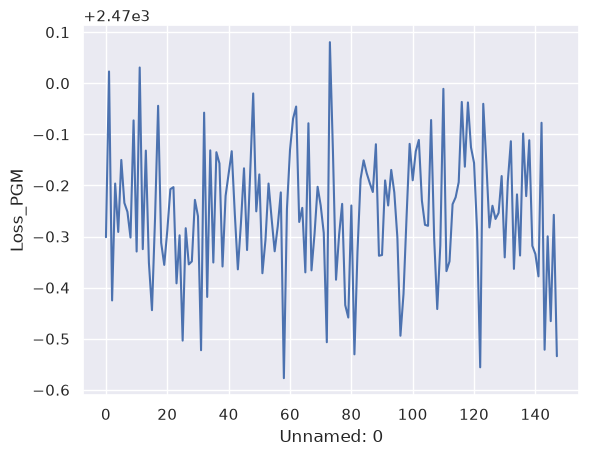

In [22]:
sns.set_theme(style="darkgrid")

loss_df_1 = pd.read_csv(training_res_smiles_split / "canonical_smiles_split_1loss_comb.csv")
loss_df_1['Split'] = pd.Series([1 for x in range(len(loss_df_1.index))])


sns.lineplot(x="Unnamed: 0", y="Loss_PGM", data=fmri)

<Axes: xlabel='Unnamed: 0', ylabel='Loss_PGM'>

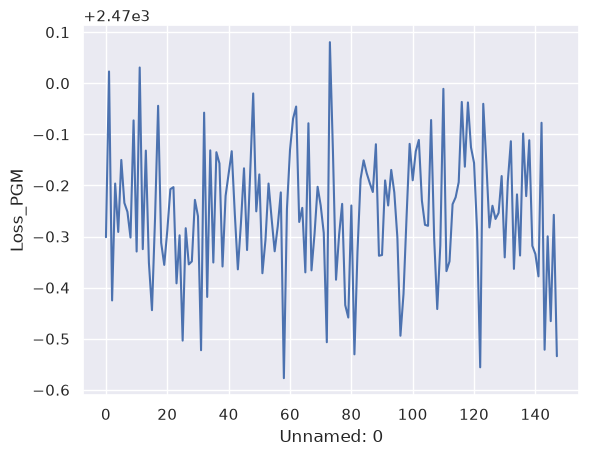

In [23]:
sns.set_theme(style="darkgrid")

loss_df_2 = pd.read_csv(training_res_smiles_split / "canonical_smiles_split_2loss_comb.csv")
loss_df_2['Split'] = pd.Series([2 for x in range(len(loss_df_2.index))])

sns.lineplot(x="Unnamed: 0", y="Loss_PGM", data=fmri)

<Axes: xlabel='Unnamed: 0', ylabel='Loss_PGM'>

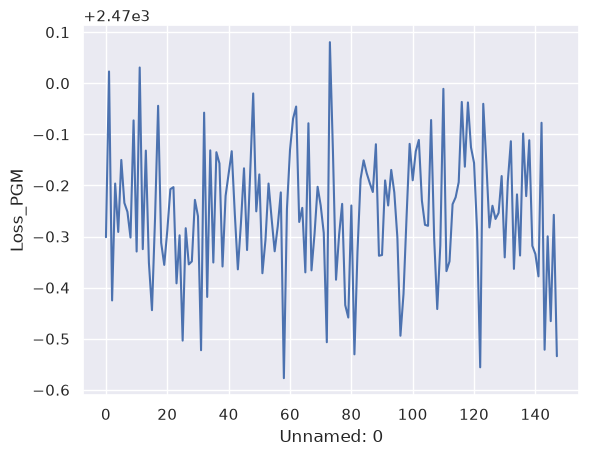

In [24]:
sns.set_theme(style="darkgrid")

loss_df_3 = pd.read_csv(training_res_smiles_split / "canonical_smiles_split_3loss_comb.csv")
loss_df_3['Split'] = pd.Series([3 for x in range(len(loss_df_3.index))])

sns.lineplot(x="Unnamed: 0", y="Loss_PGM", data=fmri)

<Axes: xlabel='Unnamed: 0', ylabel='Loss_PGM'>

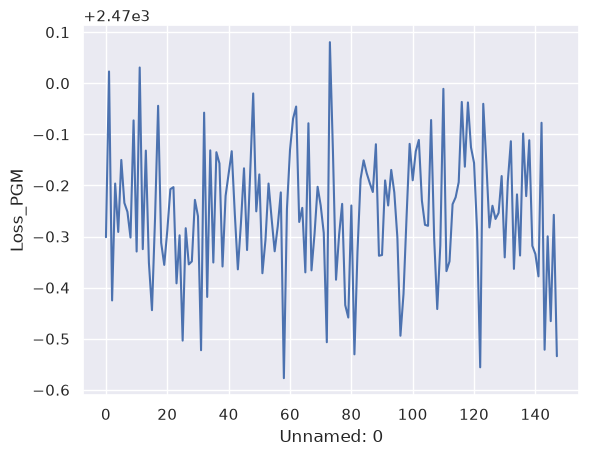

In [25]:
sns.set_theme(style="darkgrid")

loss_df_4 = pd.read_csv(training_res_smiles_split / "canonical_smiles_split_4loss_comb.csv")
loss_df_4['Split'] = pd.Series([4 for x in range(len(loss_df_4.index))])

sns.lineplot(x="Unnamed: 0", y="Loss_PGM", data=fmri)

In [27]:
# concatenate csv files (additional column that shows from what fold its from)
Loss_PGM_df = pd.concat([loss_df_0, loss_df_1, loss_df_2, loss_df_3, loss_df_4], axis=0, ignore_index=True) # concatenating along rows


In [29]:
p = (
    so.Plot(Loss_PGM_df, x="Unnamed: 0", y="Loss_PGM")
    .facet(col="Split", row="Unnamed: 0")
    .add(so.Dots())
)
p

KeyboardInterrupt: 

In [ ]:
# Link to code: https://seaborn.pydata.org/examples/jitter_stripplot.html
# Edited on: 
sns.set_theme(style="whitegrid")
iris = sns.load_dataset("iris")

# "Melt" the dataset to "long-form" or "tidy" representation
iris = iris.melt(id_vars="species", var_name="measurement")

# Initialize the figure
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=iris, x="value", y="measurement", hue="species",
    dodge=True, alpha=.25, zorder=1, legend=False,
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=iris, x="value", y="measurement", hue="species",
    dodge=.8 - .8 / 3, palette="dark", errorbar=None,
    markers="d", markersize=4, linestyle="none",
)

# Improve the legend
sns.move_legend(
    ax, loc="lower right", ncol=3, frameon=True, columnspacing=1, handletextpad=0,
)